# Demo 08 - Local-vol diagnostics, PDE repricing, and convergence

This notebook builds local volatility from the smoothed implied-surface handoff, inspects reliability diagnostics before pricing, validates the PDE stack on an anchor problem, and reprices a quote grid while keeping error and runtime trade-offs visible.

- inspect local-vol validity and denominator diagnostics
- validate the PDE solver on an anchor case
- reprice under local vol on the quote grid
- inspect convergence and runtime trade-offs

`PROFILE = "quick"` keeps the notebook compact; switch to `PROFILE = "full"` for broader sweeps.

In [7]:
# ruff: noqa: E402
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'option_pricing').exists():
            return candidate
    return start

ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / 'src'
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROFILE = 'full'
SEED = 7

In [8]:
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from IPython.display import display  # noqa: E402

from option_pricing.demos import (  # noqa: E402
    build_essvi_bridge_artifacts,
    build_localvol_pde_demo_artifacts,
    build_shared_demo_scenario,
    build_surface_demo_artifacts,
)
from option_pricing.diagnostics.vol_surface import plot as vs_plot  # noqa: E402

pd.set_option('display.max_columns', None)

scenario = build_shared_demo_scenario(profile=PROFILE, seed=SEED)
surface_art = build_surface_demo_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
)
bridge_art = build_essvi_bridge_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
    surface_artifacts=surface_art,
)
art = build_localvol_pde_demo_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
    bridge_artifacts=bridge_art,
)

headline = pd.DataFrame(
    [
        {
            'profile': art.profile,
            'input_surface_type': art.meta['input_surface_type'],
            'repricing_target_surface_type': art.meta['repricing_target_surface_type'],
            'n_repricing_strikes': len(art.meta['repricing_strikes']),
            'n_repricing_expiries': len(art.meta['repricing_expiries']),
        }
    ]
)
display(headline)

,profile,input_surface_type,repricing_target_surface_type,n_repricing_strikes,n_repricing_expiries
0,full,ESSVISmoothedSurface,ESSVISmoothedSurface,14,11


## 1) Inspect local-vol diagnostics before pricing

The local-vol report, invalid regions, and worst points are shown first so pricing results can be read with the construction diagnostics in view.

,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208672,0.277583,0.30931,0.547313


,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208563,0.283886,0.357416,0.455086


,status,count
0,clean quick-profile diagnostic grid,0


,rank,T,y,K,denom,local_var,sigma,invalid,reasons
0,1,0.12,-0.30,74.259832,0.455086,0.127746,0.357416,False,
1,2,0.12,-0.29,75.006156,0.461865,0.124504,0.352851,False,
2,3,0.12,-0.28,75.759980,0.469067,0.121267,0.348234,False,
3,4,0.12,-0.27,76.521381,0.476729,0.118036,0.343564,False,
4,5,0.12,-0.26,77.290433,0.484892,0.114812,0.338839,False,
5,6,0.12,-0.25,78.067215,0.493601,0.111595,0.334058,False,
6,7,0.12,-0.24,78.851804,0.502908,0.108387,0.329222,False,
7,8,0.12,-0.23,79.644277,0.512867,0.105189,0.324328,False,
8,9,0.12,0.30,135.310236,0.518530,0.108718,0.329723,False,
9,10,0.12,-0.22,80.444716,0.523541,0.102003,0.319379,False,


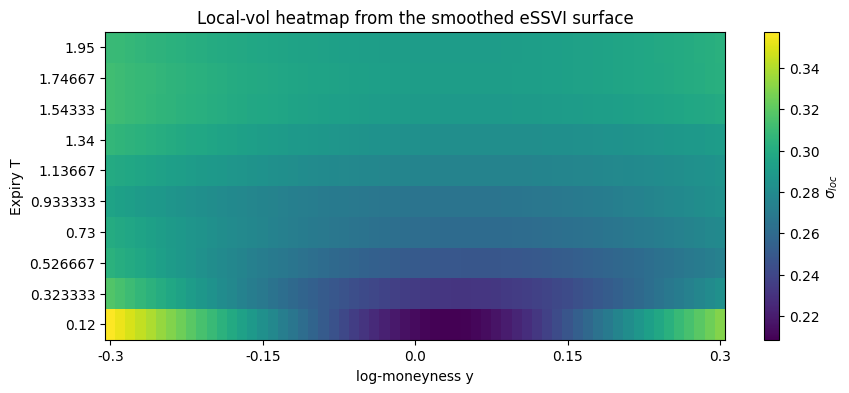

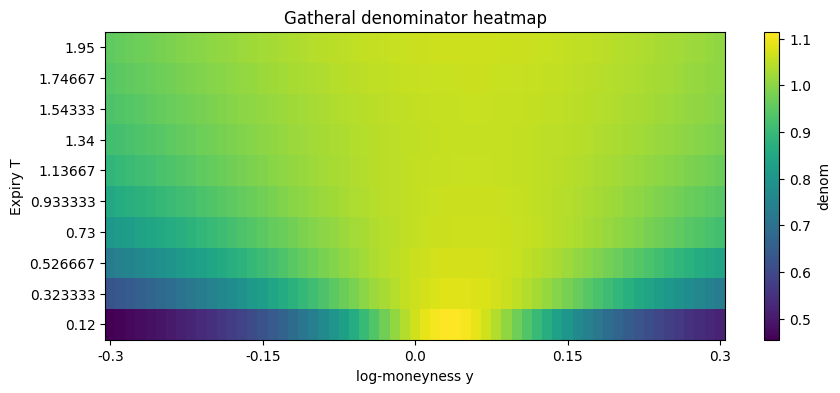

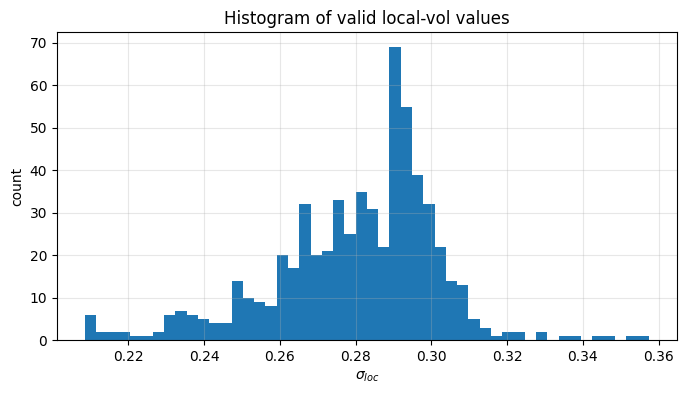

In [9]:
reason_counts = art.tables['localvol_reason_counts']
if reason_counts.empty:
    reason_counts = pd.DataFrame(
        [{'status': 'clean quick-profile diagnostic grid', 'count': 0}]
    )

display(art.bridge.tables['essvi_localvol_handoff_summary'])
display(art.tables['localvol_summary'])
display(reason_counts)
display(art.tables['localvol_worst_points'].head(10))

lv_rep = art.reports['lv_rep']
vs_plot.plot_localvol_heatmap(
    lv_rep,
    kind='sigma',
    title='Local-vol heatmap from the smoothed eSSVI surface',
)
vs_plot.plot_localvol_heatmap(
    lv_rep,
    kind='denom',
    mask_invalid=False,
    title='Gatheral denominator heatmap',
)
vs_plot.plot_localvol_histogram(
    lv_rep,
    title='Histogram of valid local-vol values',
)


## 2) Validate the PDE stack on an anchor case

A simple anchor problem makes the solver baseline easy to read before the notebook returns to the full local-vol repricing loop.

,method,advection,Nx,Nt,n,abs_err_mean,abs_err_max,runtime_ms_mean,feasible_rate
0,rannacher,upwind,151,201,2,0.000002,0.000002,87.33420,1.0
1,rannacher,upwind,151,401,2,0.000002,0.000002,207.27955,1.0
2,cn,upwind,151,401,2,0.000002,0.000002,170.28815,1.0
3,cn,upwind,151,201,2,0.000002,0.000002,83.23280,1.0
4,cn,central,151,201,2,0.000002,0.000003,91.39500,1.0
5,cn,central,101,201,2,0.000002,0.000003,73.45455,1.0
6,cn,central,151,401,2,0.000002,0.000003,180.92990,1.0
7,cn,central,101,401,2,0.000002,0.000003,142.08785,1.0
8,rannacher,central,151,401,2,0.000002,0.000003,155.91215,1.0
9,rannacher,central,101,401,2,0.000002,0.000003,129.70680,1.0


,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,coord,method,advection,spacing,Nx,Nt,ic_remedy,runtime_ms,analytic,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,logS,rannacher,central,uniform,101,201,cell_avg,66.9787,0.482634,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,66.9787,4.0
1,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,logS,rannacher,central,uniform,101,201,cell_avg,67.6019,0.482634,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,67.6019,5.0
2,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,logS,cn,central,uniform,101,201,cell_avg,72.1085,0.482634,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,72.1085,5.0
3,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,logS,rannacher,upwind,uniform,151,201,cell_avg,81.8870,0.482634,0.482633,-0.000002,0.000002,0.000003,4.60517,True,True,True,81.8870,4.0


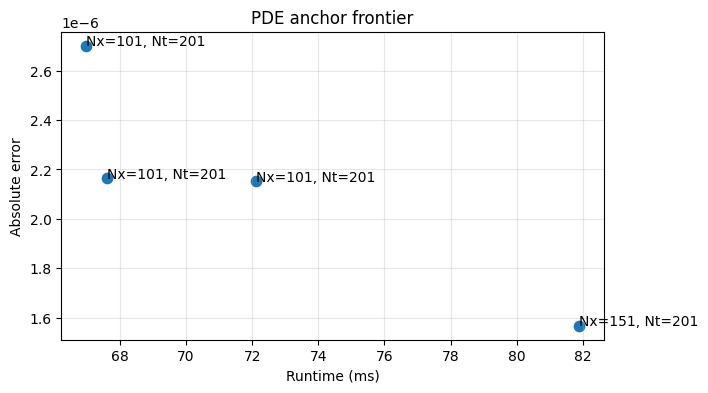

In [10]:
display(art.tables['pde_anchor_grouped'])
display(art.tables['pde_anchor_frontier'])

frontier = art.tables['pde_anchor_frontier'].copy()
if len(frontier) > 1:
    plt.figure(figsize=(7, 4))
    plt.scatter(frontier['runtime_ms'], frontier['abs_err'], s=55)
    for row in frontier.itertuples(index=False):
        plt.annotate(f'Nx={row.Nx}, Nt={row.Nt}', (row.runtime_ms, row.abs_err))
    plt.xlabel('Runtime (ms)')
    plt.ylabel('Absolute error')
    plt.title('PDE anchor frontier')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('Quick profile anchor frontier has a single point; switch to PROFILE="full" for a richer frontier plot.')


## 3) Repricing error against the implied surface

These tables and heatmaps compare local-vol PDE prices against Black-76 prices implied by the smoothed surface handoff. This is a model repricing diagnostic, kept separate from the numerical convergence sweep below.

,n_options,mean_abs_price_error,max_abs_price_error,mean_abs_iv_error_bp,max_abs_iv_error_bp,mean_runtime_ms,total_runtime_ms,Nx,Nt
0,154,0.000807,0.004451,1.017104,18.705909,1413.247764,217995.8364,151,301


,T,K,target_iv,pde_iv,abs_iv_error_bp,target_price,pde_price,abs_price_error,runtime_ms
140,2.00,78.666667,0.279923,0.280042,1.188072,29.222169,29.226619,0.004451,1519.8624
141,2.00,82.333333,0.278181,0.278276,0.951090,26.775853,26.779773,0.003920,1516.5134
99,1.00,82.333333,0.259138,0.259262,1.232994,21.949740,21.952852,0.003112,1559.4172
112,1.25,78.666667,0.266746,0.266859,1.125635,25.937260,25.940192,0.002931,1591.8320
70,0.50,78.666667,0.256121,0.256410,2.882590,22.726484,22.729244,0.002760,1314.6937
85,0.75,82.333333,0.254938,0.255067,1.288721,20.711373,20.713915,0.002542,1427.1159
71,0.50,82.333333,0.250228,0.250421,1.936274,19.465142,19.467664,0.002522,1318.9981
139,1.50,126.333333,0.262359,0.262304,0.552334,5.635179,5.632767,0.002412,1538.1272
113,1.25,82.333333,0.264359,0.264438,0.789407,23.197952,23.200321,0.002370,1590.0084
129,1.50,89.666667,0.266396,0.266453,0.574639,19.681806,19.684166,0.002360,1743.5607


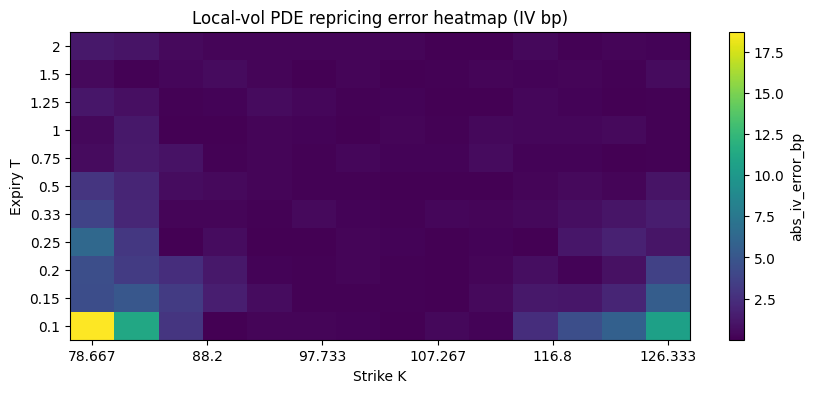

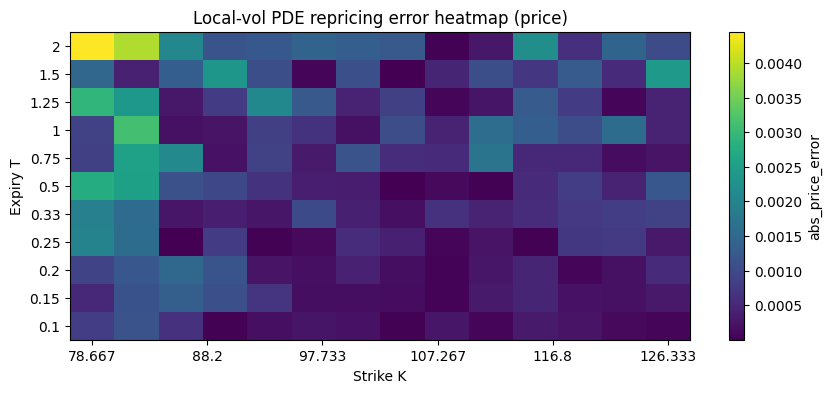

In [11]:
repricing = art.tables['repricing_grid'].copy()
worst_repricing = repricing.sort_values('abs_price_error', ascending=False).head(10)

display(art.tables['repricing_summary'])
display(
    worst_repricing[
        [
            'T',
            'K',
            'target_iv',
            'pde_iv',
            'abs_iv_error_bp',
            'target_price',
            'pde_price',
            'abs_price_error',
            'runtime_ms',
        ]
    ]
)

vs_plot.plot_repricing_heatmap(
    repricing,
    value_col='abs_iv_error_bp',
    title='Local-vol PDE repricing error heatmap (IV bp)',
)
vs_plot.plot_repricing_heatmap(
    repricing,
    value_col='abs_price_error',
    title='Local-vol PDE repricing error heatmap (price)',
)

## 4) Numerical convergence against a fine-grid PDE reference

This sweep fixes one option and compares each coarse-grid solve with a finer-grid PDE solve for the same local-vol model. The curve now isolates grid-refinement error instead of mixing in repricing mismatch to the implied-surface target.

,strike,expiry,reference_Nx,reference_Nt,reference_price,reference_runtime_ms
0,102.020134,1.0,501,1001,9.928151,5660.7779


,Nx,Nt,grid_points,pde_price,reference_price,abs_error,runtime_ms
0,101,201,20301,9.928975,9.928151,0.000824,1076.3112
1,151,301,45451,9.928455,9.928151,0.000303,1438.6872
2,201,401,80601,9.927787,9.928151,0.000365,1941.7361
3,251,501,125751,9.927805,9.928151,0.000347,2450.6954


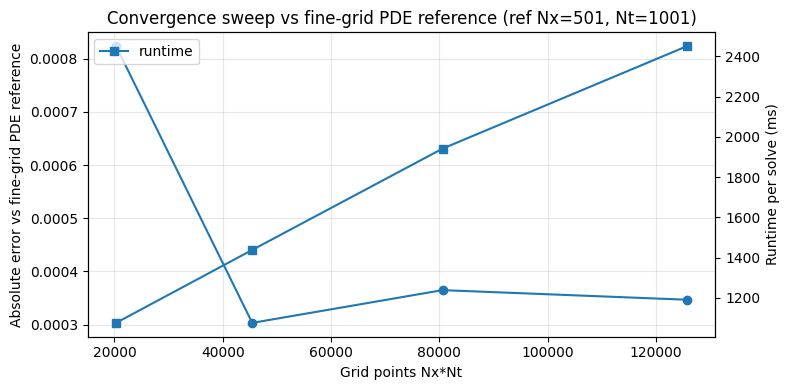

In [13]:
display(art.tables['convergence_reference'])
display(art.tables['convergence_grid'])

conv = art.tables['convergence_grid'].copy()
ref = art.tables['convergence_reference'].iloc[0]
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(conv['grid_points'], conv['abs_error'], marker='o', label='abs error')
ax1.set_xlabel('Grid points Nx*Nt')
ax1.set_ylabel('Absolute error vs fine-grid PDE reference')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(conv['grid_points'], conv['runtime_ms'], marker='s', label='runtime')
ax2.set_ylabel('Runtime per solve (ms)')

ax1.set_title(
    'Convergence sweep vs fine-grid PDE reference '
    f"(ref Nx={int(ref['reference_Nx'])}, Nt={int(ref['reference_Nt'])})"
)
fig.tight_layout()
plt.legend()
plt.show()